Number of green objects: 10
Number of blue objects: 8
Number of orange objects: 1
Number of yellow objects: 1
Number of purple objects: 1


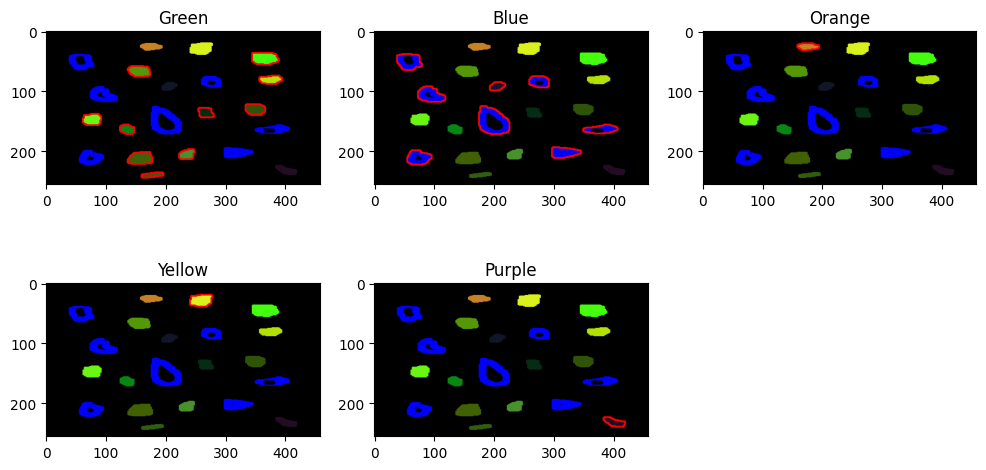

In [1]:
# Import libraries
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# This function draws the given contours on the image
def draw_contours(img, contours):
    for c in contours:
        cv.drawContours(img, [c], -1, (0, 0, 255), 2)  # red contour
    return img

# Read the original image
img_original = cv.imread('images/result_bubbles_colored.jpeg')

# Convert BGR to HSV
hsv_img = cv.cvtColor(img_original, cv.COLOR_BGR2HSV)

# Define color ranges in HSV
# Blue (dark to light)
lower_blue = np.array([100, 80, 20])
upper_blue = np.array([140, 255, 255])

# Green (dark to light)
lower_green = np.array([35, 40, 20])
upper_green = np.array([85, 255, 255])

# Yellow
lower_yellow = np.array([20, 80, 80])
upper_yellow = np.array([35, 255, 255])

# Orange
lower_orange = np.array([10, 100, 100])
upper_orange = np.array([20, 255, 255])

# Purple
lower_purple = np.array([125, 50, 20])
upper_purple = np.array([165, 255, 255])

# Create masks
mask_blue = cv.inRange(hsv_img, lower_blue, upper_blue)
mask_green = cv.inRange(hsv_img, lower_green, upper_green)
mask_yellow = cv.inRange(hsv_img, lower_yellow, upper_yellow)
mask_orange = cv.inRange(hsv_img, lower_orange, upper_orange)
mask_purple = cv.inRange(hsv_img, lower_purple, upper_purple)

# Threshold masks
_, thresh_blue = cv.threshold(mask_blue, 127, 255, cv.THRESH_BINARY)
_, thresh_green = cv.threshold(mask_green, 127, 255, cv.THRESH_BINARY)
_, thresh_yellow = cv.threshold(mask_yellow, 127, 255, cv.THRESH_BINARY)
_, thresh_orange = cv.threshold(mask_orange, 127, 255, cv.THRESH_BINARY)
_, thresh_purple = cv.threshold(mask_purple, 127, 255, cv.THRESH_BINARY)

# Find contours
contours_blue, _ = cv.findContours(thresh_blue, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
contours_green, _ = cv.findContours(thresh_green, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
contours_yellow, _ = cv.findContours(thresh_yellow, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
contours_orange, _ = cv.findContours(thresh_orange, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
contours_purple, _ = cv.findContours(thresh_purple, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

# Draw contours
img_green = img_original.copy()
img_green = draw_contours(img_green, contours_green)

img_blue = img_original.copy()
img_blue = draw_contours(img_blue, contours_blue)

img_orange = img_original.copy()
img_orange = draw_contours(img_orange, contours_orange)

img_yellow = img_original.copy()
img_yellow = draw_contours(img_yellow, contours_yellow)

img_purple = img_original.copy()
img_purple = draw_contours(img_purple, contours_purple)


# Display images
plt.figure(figsize=[12, 6])
plt.subplot(231); plt.imshow(img_green[..., ::-1]); plt.title('Green')
plt.subplot(232); plt.imshow(img_blue[..., ::-1]); plt.title('Blue')
plt.subplot(233);plt.imshow(img_orange[..., ::-1]); plt.title('Orange')
plt.subplot(234); plt.imshow(img_yellow[..., ::-1]); plt.title('Yellow')
plt.subplot(235); plt.imshow(img_purple[..., ::-1]); plt.title('Purple')

# Print number of detected objects for each color
print("Number of green objects:", len(contours_green))
print("Number of blue objects:", len(contours_blue))
print("Number of orange objects:", len(contours_orange))
print("Number of yellow objects:", len(contours_yellow))
print("Number of purple objects:", len(contours_purple))